# 📊 Exploratory Data Analysis – Insurance Claims Severity

## 🎯 Objetivo

El objetivo de este notebook es comprender la estructura, calidad y comportamiento de los datos de siniestros, con foco en identificar patrones relevantes para el modelamiento de severidad y la posterior toma de decisiones de negocio.

## 🔍 Contexto de negocio

En el contexto de seguros, entender la distribución y drivers del costo de los siniestros (loss) es clave para:
- Evaluar riesgo
- Diseñar estrategias de pricing
- Optimizar la rentabilidad del portafolio

## 🧱 Alcance

En este análisis se abordará:
- Revisión de estructura y tipos de variables
- Identificación de variables categóricas y continuas
- Análisis de la variable objetivo (loss)
- Detección de patrones iniciales y posibles transformaciones

## 🚀 Resultado esperado

Al finalizar este notebook se espera contar con:
- Un entendimiento claro del dataset
- Hipótesis sobre variables relevantes
- Lineamientos para feature engineering

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

# Cargar datos
df = pd.read_csv("train.csv")

# Vista inicial
df.head()

,id,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,cat9,cat10,cat11,cat12,cat13,cat14,cat15,cat16,cat17,cat18,cat19,cat20,cat21,cat22,cat23,cat24,cat25,cat26,cat27,cat28,cat29,cat30,cat31,cat32,cat33,cat34,cat35,cat36,cat37,cat38,cat39,cat40,cat41,cat42,cat43,cat44,cat45,cat46,cat47,cat48,cat49,cat50,cat51,cat52,cat53,cat54,cat55,cat56,cat57,cat58,cat59,cat60,cat61,cat62,cat63,cat64,cat65,cat66,cat67,cat68,cat69,cat70,cat71,cat72,cat73,cat74,cat75,cat76,cat77,cat78,cat79,cat80,cat81,cat82,cat83,cat84,cat85,cat86,cat87,cat88,cat89,cat90,cat91,cat92,cat93,cat94,cat95,cat96,cat97,cat98,cat99,cat100,cat101,cat102,cat103,cat104,cat105,cat106,cat107,cat108,cat109,cat110,cat111,cat112,cat113,cat114,cat115,cat116,cont1,cont2,cont3,cont4,cont5,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13,cont14,loss
0,1,A,B,A,B,A,A,A,A,B,A,B,A,A,A,A,A,A,A,A,A,A,A,B,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,B,A,D,B,B,D,D,B,D,C,B,D,B,A,A,A,A,A,D,B,C,E,A,C,T,B,G,A,A,I,E,G,J,G,BU,BC,C,AS,S,A,O,LB,0.726300,0.245921,0.187583,0.789639,0.310061,0.718367,0.335060,0.30260,0.67135,0.83510,0.569745,0.594646,0.822493,0.714843,2213.18
1,2,A,B,A,A,A,A,A,A,B,B,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,D,B,B,D,D,A,B,C,B,D,B,A,A,A,A,A,D,D,C,E,E,D,T,L,F,A,A,E,E,I,K,K,BI,CQ,A,AV,BM,A,O,DP,0.330514,0.737068,0.592681,0.614134,0.885834,0.438917,0.436585,0.60087,0.35127,0.43919,0.338312,0.366307,0.611431,0.304496,1283.60
2,5,A,B,A,A,B,A,A,A,B,B,B,B,B,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,B,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,D,B,B,B,D,B,D,C,B,B,B,A,A,A,A,A,D,D,C,E,E,A,D,L,O,A,B,E,F,H,F,A,AB,DK,A,C,AF,A,I,GK,0.261841,0.358319,0.484196,0.236924,0.397069,0.289648,0.315545,0.27320,0.26076,0.32446,0.381398,0.373424,0.195709,0.774425,3005.09
3,10,B,B,A,B,A,A,A,A,B,A,A,A,A,A,A,A,A,A,A,A,A,A,B,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,B,A,A,A,D,B,B,D,D,D,B,C,B,D,B,A,A,A,A,A,D,D,C,E,E,D,T,I,D,A,A,E,E,I,K,K,BI,CS,C,N,AE,A,O,DJ,0.321594,0.555782,0.527991,0.373816,0.422268,0.440945,0.391128,0.31796,0.32128,0.44467,0.327915,0.321570,0.605077,0.602642,939.85
4,11,A,B,A,B,A,A,A,A,B,B,A,B,A,A,A,A,A,A,A,A,A,A,B,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,A,B,A,A,A,A,D,B,D,B,D,B,B,C,B,B,C,A,A,A,B,H,D,B,D,E,E,A,P,F,J,A,A,D,E,K,G,B,H,C,C,Y,BM,A,K,CK,0.273204,0.159990,0.527991,0.473202,0.704268,0.178193,0.247408,0.24564,0.22089,0.21230,0.204687,0.202213,0.246011,0.432606,2763.85


## 1. Carga y vista inicial de los datos

In [4]:
print("Shape:", df.shape)

Shape: (188318, 132)


## 2. Estructura general del dataset

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 188318 entries, 0 to 188317
Columns: 132 entries, id to loss
dtypes: float64(15), int64(1), str(116)
memory usage: 189.7 MB


In [6]:
cat_cols = [col for col in df.columns if col.startswith("cat")]
cont_cols = [col for col in df.columns if col.startswith("cont")]
target_col = "loss"

print("Cantidad de variables categóricas:", len(cat_cols))
print("Cantidad de variables continuas:", len(cont_cols))
print("Variable objetivo:", target_col)

Cantidad de variables categóricas: 116
Cantidad de variables continuas: 14
Variable objetivo: loss


### Observaciones iniciales
En esta etapa se revisa la estructura general del dataset, identificando la cantidad de registros, tipos de datos y la composición de variables categóricas, continuas y objetivo. Esto permite definir las líneas iniciales de exploración y anticipar necesidades de preprocesamiento.

## 3. Análisis de la variable objetivo (loss)

In [7]:
df["loss"].describe()

count    188318.000000
mean       3037.337686
std        2904.086186
min           0.670000
25%        1204.460000
50%        2115.570000
75%        3864.045000
max      121012.250000
Name: loss, dtype: float64

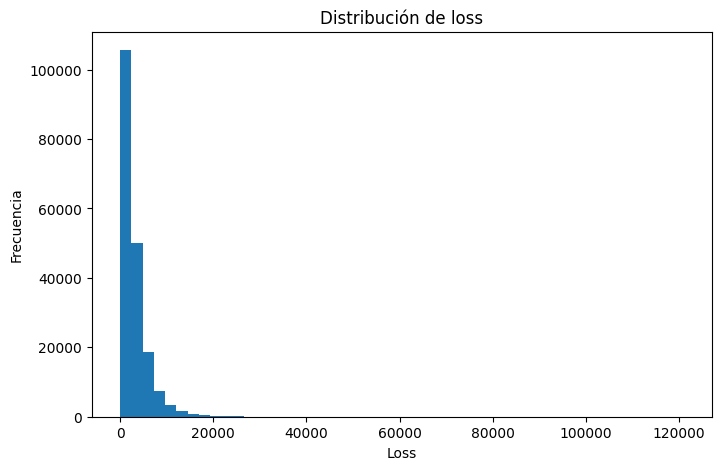

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df["loss"], bins=50)
plt.title("Distribución de loss")
plt.xlabel("Loss")
plt.ylabel("Frecuencia")
plt.show()

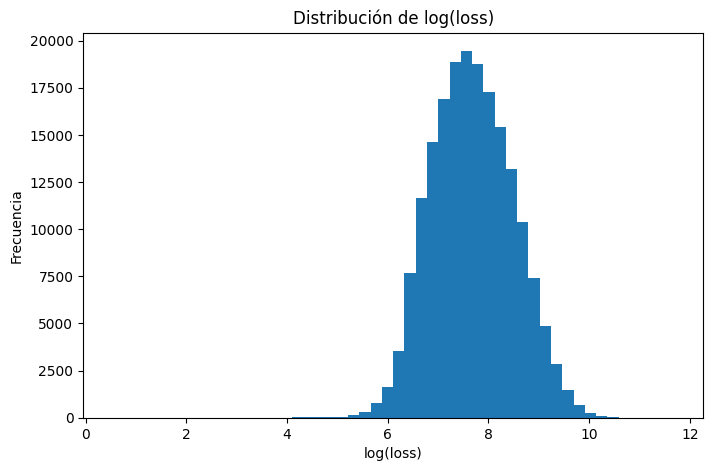

In [9]:
plt.figure(figsize=(8,5))
plt.hist(np.log1p(df["loss"]), bins=50)
plt.title("Distribución de log(loss)")
plt.xlabel("log(loss)")
plt.ylabel("Frecuencia")
plt.show()

### Observaciones sobre la variable objetivo

- La variable `loss` presenta una distribución altamente sesgada hacia la derecha (heavy tail), lo que indica la presencia de siniestros de alto costo poco frecuentes.
- Este comportamiento es típico en problemas de seguros, donde una pequeña proporción de casos concentra gran parte de las pérdidas.
- La transformación logarítmica (`log(loss)`) permite estabilizar la varianza y obtener una distribución más cercana a normal, lo que facilita el modelamiento.

### Implicancias

- Se considerará modelar sobre `log(loss)` en lugar de `loss` directamente.
- Se deben utilizar métricas robustas frente a outliers (como MAE).

## 4. Relación entre variables y la severidad (loss)

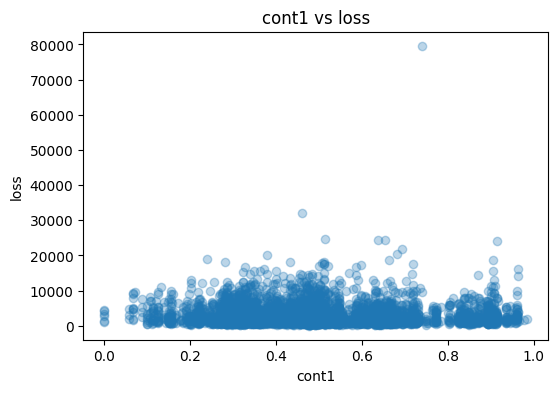

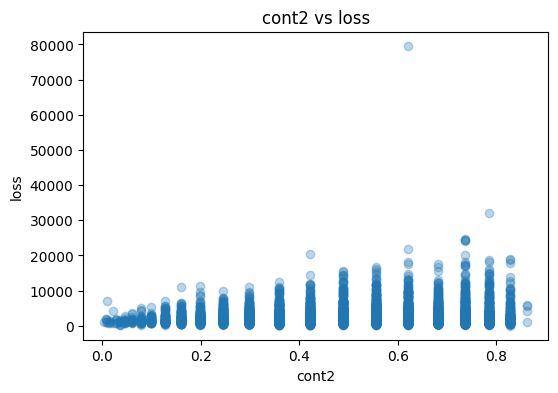

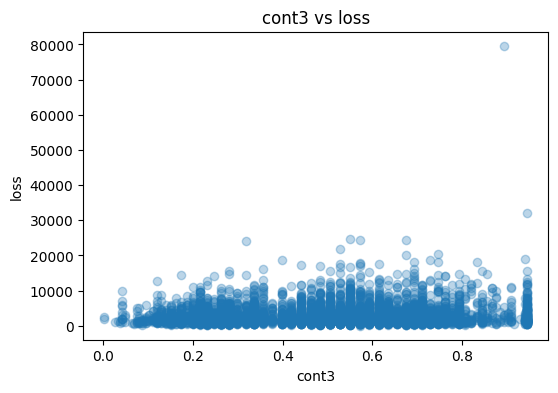

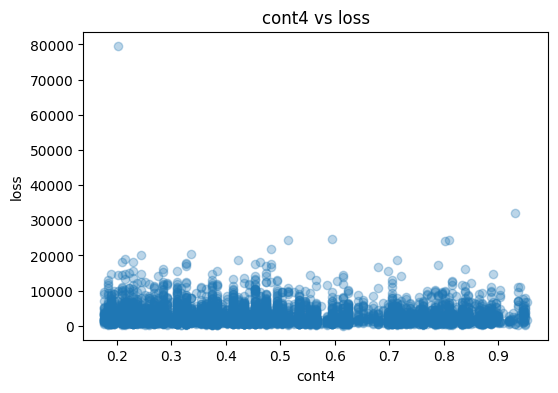

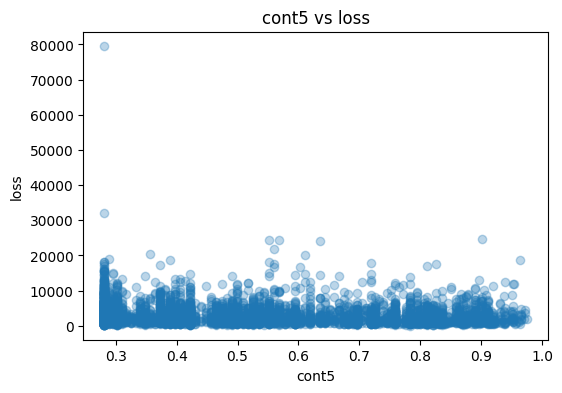

In [10]:
sample_df = df.sample(5000, random_state=42)

for col in cont_cols[:5]:
    plt.figure(figsize=(6,4))
    plt.scatter(sample_df[col], sample_df["loss"], alpha=0.3)
    plt.title(f"{col} vs loss")
    plt.xlabel(col)
    plt.ylabel("loss")
    plt.show()

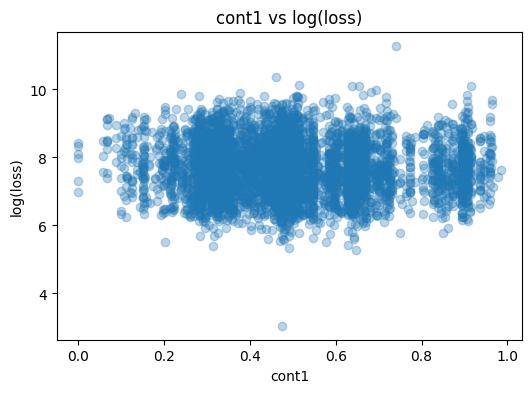

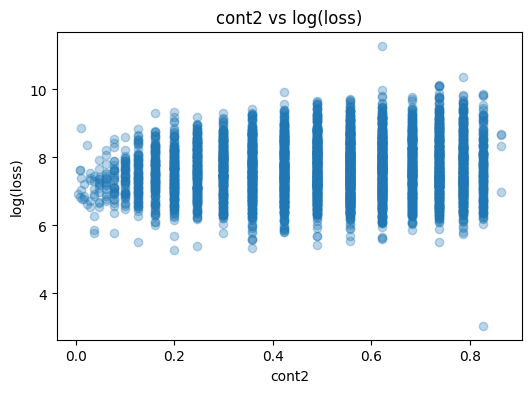

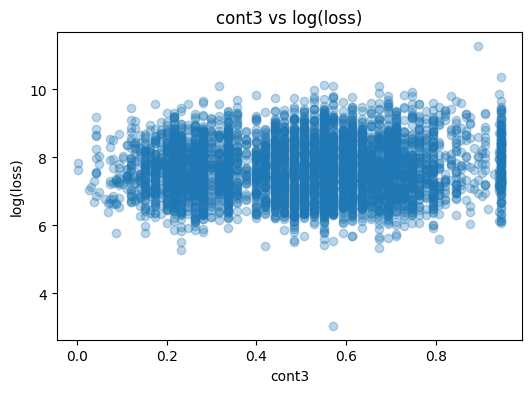

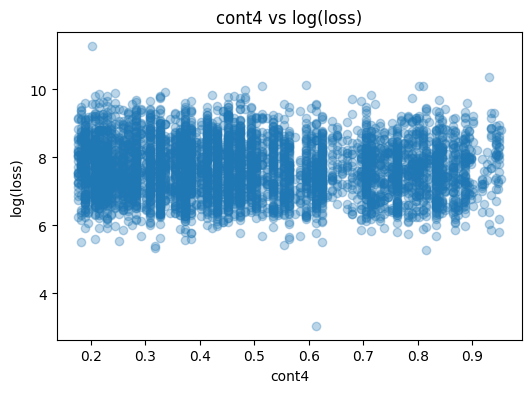

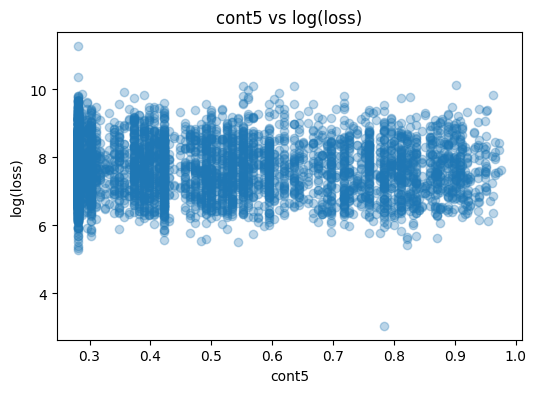

In [11]:
sample_df["log_loss"] = np.log1p(sample_df["loss"])

for col in cont_cols[:5]:
    plt.figure(figsize=(6,4))
    plt.scatter(sample_df[col], sample_df["log_loss"], alpha=0.3)
    plt.title(f"{col} vs log(loss)")
    plt.xlabel(col)
    plt.ylabel("log(loss)")
    plt.show()

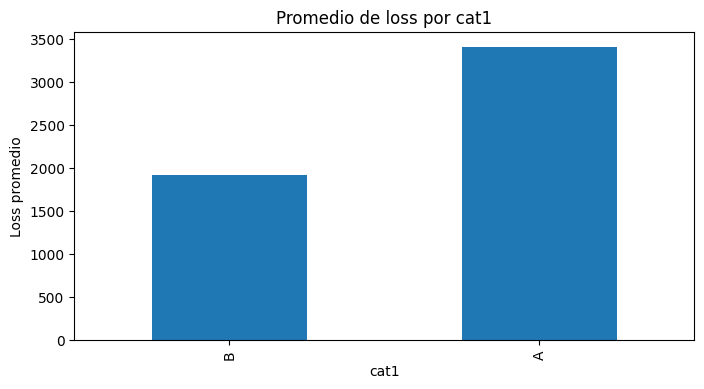

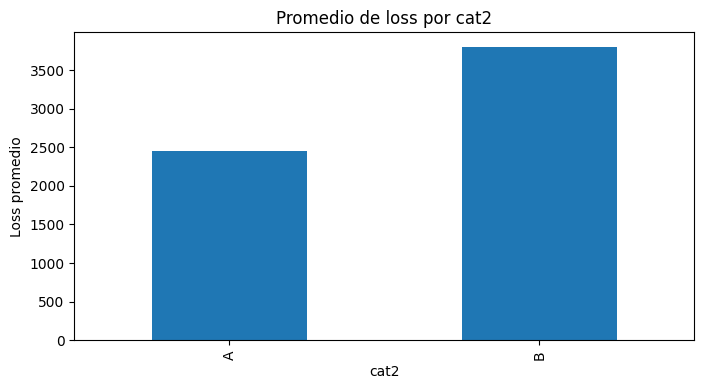

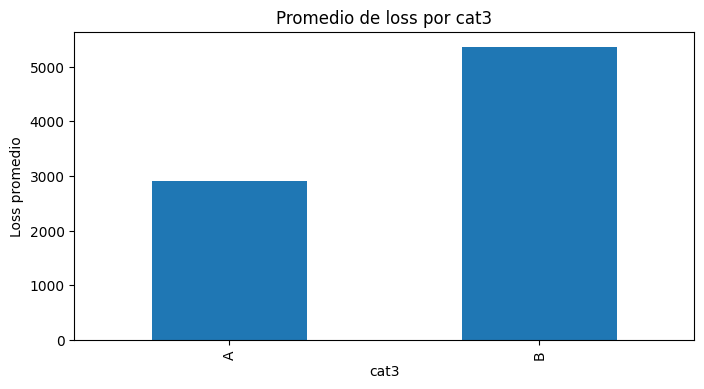

In [12]:
for col in cat_cols[:3]:
    plt.figure(figsize=(8,4))
    df.groupby(col)["loss"].mean().sort_values().plot(kind="bar")
    plt.title(f"Promedio de loss por {col}")
    plt.ylabel("Loss promedio")
    plt.show()

### Observaciones sobre relaciones con la variable objetivo

- Las variables continuas muestran relaciones no lineales con la severidad, lo que sugiere el uso de modelos flexibles.
- Se observan diferencias relevantes en el promedio de `loss` entre categorías, indicando que las variables categóricas contienen información importante para la predicción.
- La transformación logarítmica mejora la visualización de patrones.

### Implicancias

- Se priorizarán modelos capaces de capturar relaciones no lineales (ej: boosting).
- Las variables categóricas serán tratadas cuidadosamente mediante encoding, ya que contienen señal relevante.

## 5. Cardinalidad de variables categóricas

In [13]:
cardinality = df[cat_cols].nunique().sort_values(ascending=False)

cardinality.head(10)

cat116    326
cat110    131
cat109     84
cat113     61
cat112     51
cat115     23
cat105     20
cat107     20
cat101     19
cat114     19
dtype: int64

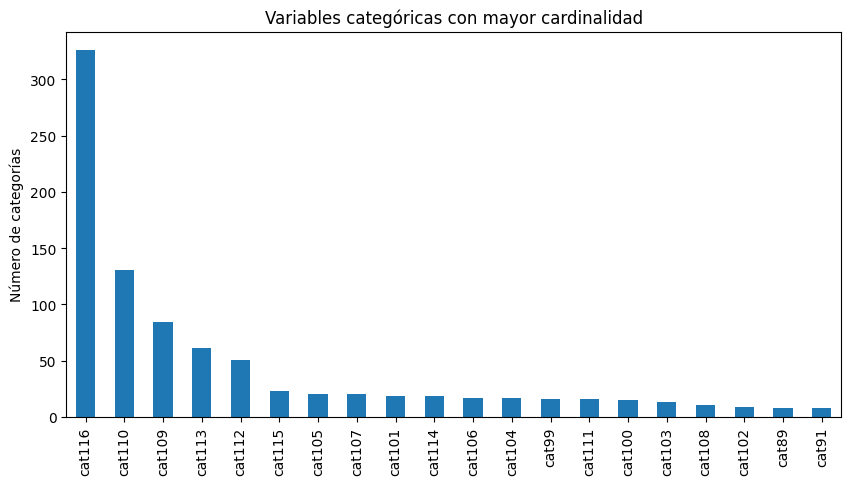

In [14]:
plt.figure(figsize=(10,5))
cardinality.head(20).plot(kind="bar")
plt.title("Variables categóricas con mayor cardinalidad")
plt.ylabel("Número de categorías")
plt.show()

In [16]:
baja_cardinalidad = [col for col in cat_cols if df[col].nunique() <= 10]
media_cardinalidad = [col for col in cat_cols if 10 < df[col].nunique() <= 50]
alta_cardinalidad = [col for col in cat_cols if df[col].nunique() > 50]

print("Variables de baja cardinalidad:", len(baja_cardinalidad))
print("Variables de media cardinalidad:", len(media_cardinalidad))
print("Variables de alta cardinalidad:", len(alta_cardinalidad))

Variables de baja cardinalidad: 99
Variables de media cardinalidad: 12
Variables de alta cardinalidad: 5


### Observaciones sobre cardinalidad

- Existen variables categóricas con alta cardinalidad, lo que puede generar problemas de dimensionalidad si se utiliza one-hot encoding.
- Se observa una combinación de variables de baja, media y alta cardinalidad.

### Implicancias

- Se utilizarán diferentes estrategias de encoding según la cardinalidad:
  - Baja cardinalidad: one-hot encoding
  - Media cardinalidad: encoding más eficiente (ej. target encoding)
  - Alta cardinalidad: técnicas como target encoding
- El tratamiento adecuado de estas variables será clave para el desempeño del modelo.

## 6. Análisis de negocio: concentración del riesgo

In [17]:
df_sorted = df.sort_values("loss", ascending=False).reset_index(drop=True)

In [18]:
df_sorted["loss_acumulado"] = df_sorted["loss"].cumsum()
df_sorted["pct_loss_acumulado"] = df_sorted["loss_acumulado"] / df_sorted["loss"].sum()

df_sorted["pct_clientes"] = (df_sorted.index + 1) / len(df_sorted)

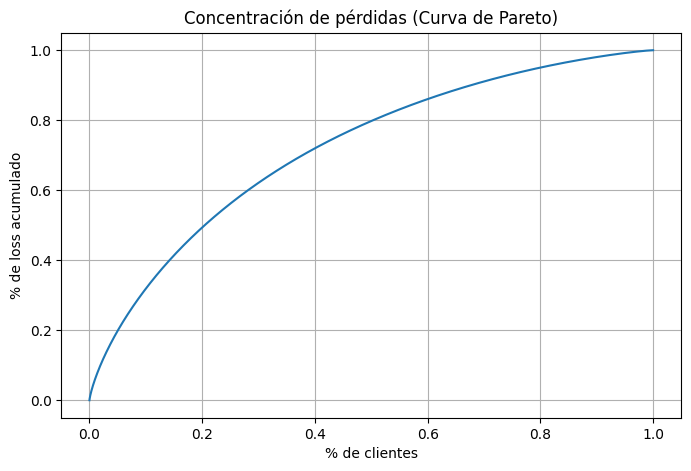

In [19]:
plt.figure(figsize=(8,5))
plt.plot(df_sorted["pct_clientes"], df_sorted["pct_loss_acumulado"])
plt.xlabel("% de clientes")
plt.ylabel("% de loss acumulado")
plt.title("Concentración de pérdidas (Curva de Pareto)")
plt.grid()
plt.show()

In [20]:
top_20 = df_sorted[df_sorted["pct_clientes"] <= 0.2]["loss"].sum()
total_loss = df_sorted["loss"].sum()

print("Porcentaje del loss en el 20% superior:", top_20 / total_loss)

Porcentaje del loss en el 20% superior: 0.49365263609919324


### Observaciones de negocio

- Se observa que una proporción reducida de los siniestros concentra un alto porcentaje de las pérdidas totales.
- Este comportamiento es consistente con problemas de seguros, donde los eventos de alta severidad tienen un impacto desproporcionado en la rentabilidad.

### Implicancias

- Es clave identificar y modelar correctamente estos casos de alto impacto.
- Estrategias de pricing diferenciadas podrían mejorar significativamente la rentabilidad del portafolio.
- La correcta estimación del riesgo en estos segmentos es crítica para la toma de decisiones.

# 📌 Conclusiones EDA

## 🔍 Principales hallazgos

- La variable objetivo `loss` presenta una distribución altamente sesgada (heavy tail), lo que sugiere la necesidad de transformaciones (por ejemplo, log).
- El dataset contiene un alto número de variables categóricas, algunas con alta cardinalidad, lo que requerirá técnicas de encoding adecuadas.
- No se observan problemas significativos de datos faltantes, lo que facilita el modelamiento.

## 🧠 Implicancias para el modelamiento

- Se utilizará transformación logarítmica sobre `loss` para estabilizar la varianza.
- Se evaluará el uso de técnicas como target encoding para variables categóricas.
- Se priorizarán modelos capaces de capturar relaciones no lineales.

## ➡️ Siguiente paso

El siguiente paso consiste en realizar feature engineering, incorporando transformaciones y nuevas variables que permitan mejorar la capacidad predictiva de los modelos.